### Group ID: 107
### Group Members Name with Student ID:
1. MANISH GARG -  2024aa05118
2. SUKAMATI NAVEEN KUMAR - 2024aa05078
3. GAURAV DHAMI  - 2024aa05077
4. HARSHIT KUMAR HALWAN  - 2024aa05928



# Scenario

A pharmaceutical company is conducting clinical trials to evaluate the effectiveness of three antiretroviral drug combinations for treating HIV-positive patients. Due to the ethical and cost constraints of clinical trials, it is critical to identify the most effective treatment regimen using the least number of patients. Each treatment (or “arm”) can lead to different outcomes depending on patient responses. The effectiveness of each treatment is evaluated using a reward function derived from the improvement in patients’ immune system markers and survival status.



# Problem Definition

You are provided with a clinical dataset where each record corresponds to a patient, including the treatment they received and the resulting health outcomes. Your task is to simulate a clinical trial environment using various MAB strategies to sequentially recommend treatments and observe outcomes. The objective is to maximize the overall success rate across trials by identifying and favouring the most effective treatment.



# Dataset

You will be provided a dataset containing the following fields:

* ***Age (age)***: Patient's age in years at baseline.
* ***Weight (wtkg)***: Continuous feature representing weight in kilograms at baseline.
* ***Gender (gender)***: Binary indicator of gender (0 = Female, 1 = Male).
* ***CD4 Counts (cd40, cd420)***: Integer values representing CD4 counts at baseline and 20+/-5 weeks.
* ***Treatment Indicator (trt)***: Categorical feature indicating the type of treatment received (0 = ZDV only, 1 = ZDV + ddI, 2 = ZDV + Zal, 3 = ddI only).
* ***Censoring Indicator (label)***: Binary indicator (1 = failure, 0 = censoring) denoting patient status.


***Link for accessing dataset:***
https://drive.google.com/file/d/1LYfIrJ4VEEGeyOsSt_qoLk7FaAv5Jfx-/view?usp=sharing


# Environment Setup

***treatmentTypes (Actions):*** The treatment types (trt)
* Arm 0: ZDV only
* Arm 1: ZDV + ddI
* Arm 2: ZDV + Zal
* Arm 3: ddI only


**Reward Function:**

Reward `r` is defined as:

`r = 1, if (label == 0) and (cd420 > cd40)`

`r = 0, otherwise`


  
This reward represents a successful treatment outcome as an increase in CD4 count and survival.

**Assumptions:**

*Number of Iterations:* Run the simulation for at least 1000 trials (iterations), with the option to extend the number of trials depending on the convergence behavior or observed reward trends. In each iteration, simulate one patient trial using one of the bandit policies.


# Requirements and Deliverables:
Implement the Multi-Arm Bandit Problem for the given above scenario for all the below mentioned policy methods.

### Initialize constants

In [ ]:
# Constants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from google.colab import drive # Import drive from google.colab

# Load Dataset (0.5M)

In [ ]:
# Code for Dataset loading and print dataset statistics
# Load the dataset

# 1. Mount Google Drive
drive.mount('/content/drive' , force_remount=True)
print("Google Drive mounted successfully.")
filepath = '/content/drive/My Drive/Clinical_Trial.csv'
# Replace with your file's path
df = pd.read_csv(filepath)

# Create a list of new values (must have the same number of elements as rows in df)
new_column_values = [i * 1 for i in range(len(df))] # Example: creating sequential values

# Add a new column named 'patientid' to randomly slect patient data
df['patientid'] = new_column_values

print("Dataset loaded successfully.")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset info:\n", df.info())
print("\nUnique treatmentTypes in the dataset:", df['trt'].unique())


Mounted at /content/drive
Google Drive mounted successfully.
Dataset loaded successfully.

First 5 rows:
   age     wtkg  gender  cd40  cd420  trt  label  patientid
0   48  89.8128       0   422    477    2      0          0
1   61  49.4424       0   162    218    3      1          1
2   45  88.4520       1   326    274    3      0          2
3   47  85.2768       1   287    394    3      0          3
4   43  66.6792       1   504    353    0      0          4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        2139 non-null   int64  
 1   wtkg       2139 non-null   float64
 2   gender     2139 non-null   int64  
 3   cd40       2139 non-null   int64  
 4   cd420      2139 non-null   int64  
 5   trt        2139 non-null   int64  
 6   label      2139 non-null   int64  
 7   patientid  2139 non-null   int64  
dtypes: float64(1), int64(7)


# Design a Clinical Trial Environment (0.5M)

In [ ]:
# Code for environment setup along with reward function

class ClinicalTrialEnvironment:
  def __init__(self, data):
        self.data = data
        self.treatmentTypes = sorted(self.data['trt'].unique())
        self.num_treatmentTypes = len(self.treatmentTypes)
        self.arm_map = {arm_name: i for i, arm_name in enumerate(self.treatmentTypes)}
        self.reverse_arm_map = {i: arm_name for i, arm_name in enumerate(self.treatmentTypes)}
        print(f"\nBandit Environment Initialized with {self.num_treatmentTypes} treatmentTypes: {self.treatmentTypes}")

  def get_reward(self, arm_index, patient_id):
        arm_name = self.reverse_arm_map[arm_index]
        # print(f"\narm_name ", arm_name)
        patient_data = self.data[(self.data['trt'] == arm_name) & (self.data['patientid'] == patient_id)]

        if patient_data.empty:
            # This should ideally not happen if patient_id is valid for the arm
            # For simulation, we might need to handle cases where a patient_id
            # does not exist for a given arm in the provided dataset.
            # For simplicity, we'll assume patient_id in simulation will correspond
            # to available data points for that arm.
            return 0 # No data, no reward

        # Assuming one row per patient per arm in the trial
        label = patient_data['label'].iloc[0]
        cd40 = patient_data['cd40'].iloc[0]
        cd420 = patient_data['cd420'].iloc[0]

        # Reward function: r = 1, if (label == 0) and (cd420 > cd40); r = 0, otherwise
        reward = 1 if (label == 0) and (cd420 > cd40) else 0
        return reward


# Helper function to simulate a patient trial
def simulate_patient_trial(bandit_env, policy, iteration_num, rewards_per_arm, counts_per_arm, total_iterations):
    # Select a random patient ID available in the entire dataset for this iteration
    # This ensures we pick from available patient data for reward calculation
    available_patient_ids = bandit_env.data['patientid'].unique()
    current_patient_id = np.random.choice(available_patient_ids)

    # Policy decides which arm (treatment) to select
    # print("rewards_per_arm", rewards_per_arm)
    # print("counts_per_arm", counts_per_arm)
    # print("iteration_num", iteration_num)
    # print("bandit_env.num_treatmentTypes", bandit_env.num_treatmentTypes)
    selected_arm_index = policy.select_arm(rewards_per_arm, counts_per_arm, iteration_num, bandit_env.num_treatmentTypes)
    selected_arm_name = bandit_env.reverse_arm_map[selected_arm_index]

    # Get the reward for the selected arm and patient
    reward = bandit_env.get_reward(selected_arm_index, current_patient_id)

    # Update counts and rewards for the selected arm
    counts_per_arm[selected_arm_index] += 1
    rewards_per_arm[selected_arm_index] += reward

    return selected_arm_index, reward, selected_arm_name

# Initialize the bandit environment
bandit_env = ClinicalTrialEnvironment(df)



Bandit Environment Initialized with 4 treatmentTypes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


# Using Random Policy (0.5M)
Implement a random policy for treatment selection and print each 100th iteration. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a random policy
class RandomPolicy:
    def __init__(self, num_treatmentTypes):
        self.num_treatmentTypes = num_treatmentTypes
        print("Random Policy Initialized.")

    def select_arm(self, rewards_per_arm, counts_per_arm, iteration_num, num_treatmentTypes):
        return random.randrange(self.num_treatmentTypes)

# Using Greedy Policy (1M)
Implement the Greedy policy that always selects the treatment with the highest average reward and print each 100th iteration. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a greedy policy
class GreedyPolicy:
    def __init__(self):
        print("Greedy Policy Initialized.")

    def select_arm(self, rewards_per_arm, counts_per_arm, iteration_num, num_treatmentTypes):
        # Prevent division by zero for treatmentTypes not yet tried
        # Prioritize untried treatmentTypes, or pick randomly among them
        untried_treatmentTypes = [i for i, count in enumerate(counts_per_arm) if count == 0]
        if untried_treatmentTypes:
            return random.choice(untried_treatmentTypes)
        else:
            avg_rewards = np.array([r / c if c > 0 else -np.inf for r, c in zip(rewards_per_arm, counts_per_arm)])
            return np.argmax(avg_rewards)

# Using Epsilon-Greedy Policy (1.5M)
Implement the ε-Greedy policy with ε = 0.1, 0.2, 0.5. Report iteration-wise selections and rewards. Determine which ε yields the best result. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a epsilon-greedy policy
class EpsilonGreedyPolicy:
    def __init__(self, epsilon):
        self.epsilon = epsilon
        print(f"Epsilon-Greedy Policy Initialized with epsilon={epsilon}")

    def select_arm(self, rewards_per_arm, counts_per_arm, iteration_num, num_treatmentTypes):
        if random.random() < self.epsilon:
            # Explore: select a random arm
            return random.randrange(num_treatmentTypes)
        else:
            # Exploit: select the best arm (greedy choice)
            untried_treatmentTypes = [i for i, count in enumerate(counts_per_arm) if count == 0]
            if untried_treatmentTypes:
                return random.choice(untried_treatmentTypes)
            else:
                avg_rewards = np.array([r / c if c > 0 else -np.inf for r, c in zip(rewards_per_arm, counts_per_arm)])
                return np.argmax(avg_rewards)

# Using UCB (1M)
Implement the UCB algorithm for treatment selection and print each 100th iteration. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a UCB
class UCBPolicy:
    def __init__(self, num_treatmentTypes):
        self.num_treatmentTypes = num_treatmentTypes
        print("UCB Policy Initialized.")

    def select_arm(self, rewards_per_arm, counts_per_arm, iteration_num, num_treatmentTypes):
        # Ensure all treatmentTypes have been tried at least once in the initial rounds
        for arm_index in range(num_treatmentTypes):
            if counts_per_arm[arm_index] == 0:
                return arm_index # Play each arm once to get initial estimates

        # Calculate UCB values
        ucb_values = np.zeros(num_treatmentTypes)
        total_plays = sum(counts_per_arm)
        if total_plays == 0: # Should not happen if all treatmentTypes played once
            return random.randrange(num_treatmentTypes)

        for arm_index in range(num_treatmentTypes):
            avg_reward = rewards_per_arm[arm_index] / counts_per_arm[arm_index]
            # UCB formula: avg_reward + sqrt(2 * ln(total_plays) / N_a)
            confidence_bound = np.sqrt(2 * np.log(total_plays) / counts_per_arm[arm_index])
            ucb_values[arm_index] = avg_reward + confidence_bound
        return np.argmax(ucb_values)

# Plot the cumulative rewards for all policies on a single graph to compare their performance. (0.5M)

****************************Starting Iterations**********************
Environment:  <__main__.ClinicalTrialEnvironment object at 0x7eda7f039cd0>
num_treatmentTypes:  4
Random Policy Initialized.

--- Running Simulation for RandomPolicy ---
Iteration 99: Selected Arm = 3, Reward = 1, Cumulative Reward = 13
Iteration 199: Selected Arm = 1, Reward = 0, Cumulative Reward = 25
Iteration 299: Selected Arm = 2, Reward = 0, Cumulative Reward = 36
Iteration 399: Selected Arm = 1, Reward = 0, Cumulative Reward = 53
Iteration 499: Selected Arm = 0, Reward = 0, Cumulative Reward = 61
Iteration 599: Selected Arm = 0, Reward = 0, Cumulative Reward = 70
Iteration 699: Selected Arm = 1, Reward = 0, Cumulative Reward = 83
Iteration 799: Selected Arm = 2, Reward = 0, Cumulative Reward = 95
Iteration 899: Selected Arm = 3, Reward = 0, Cumulative Reward = 106
Iteration 999: Selected Arm = 0, Reward = 0, Cumulative Reward = 120
--- Simulation for RandomPolicy Finished. Total Cumulative Reward: 120 ---
Gree

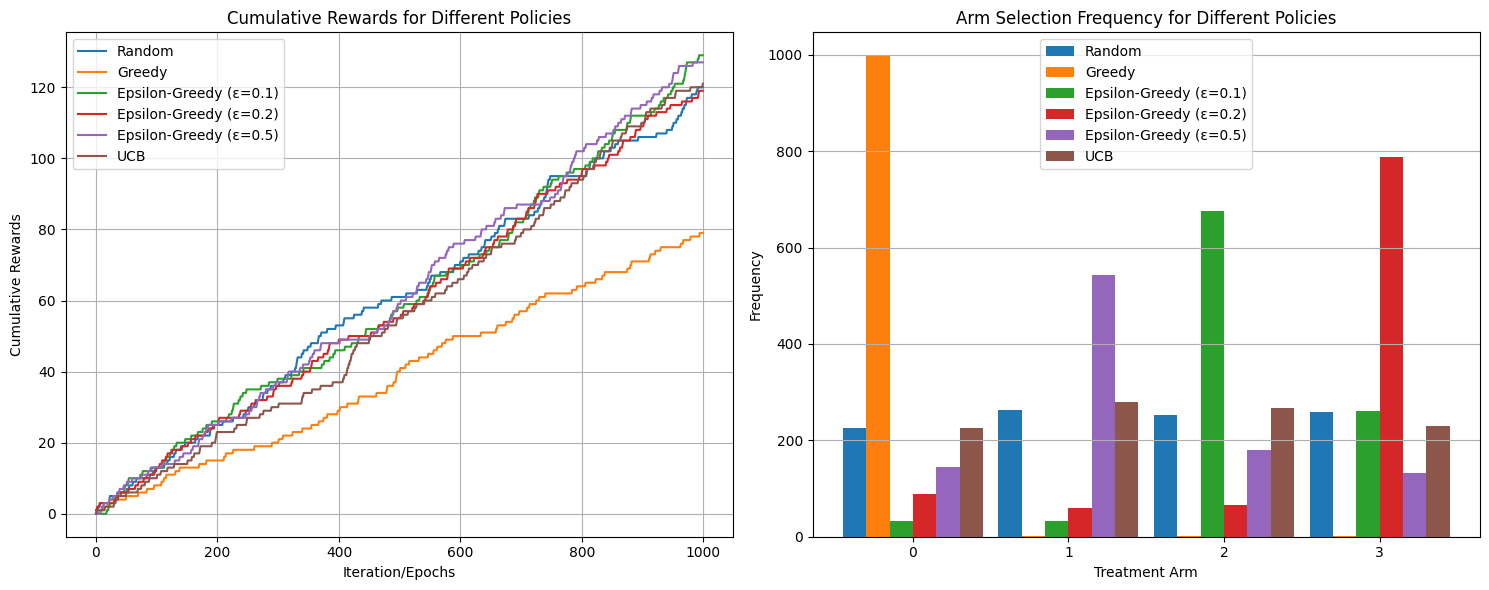

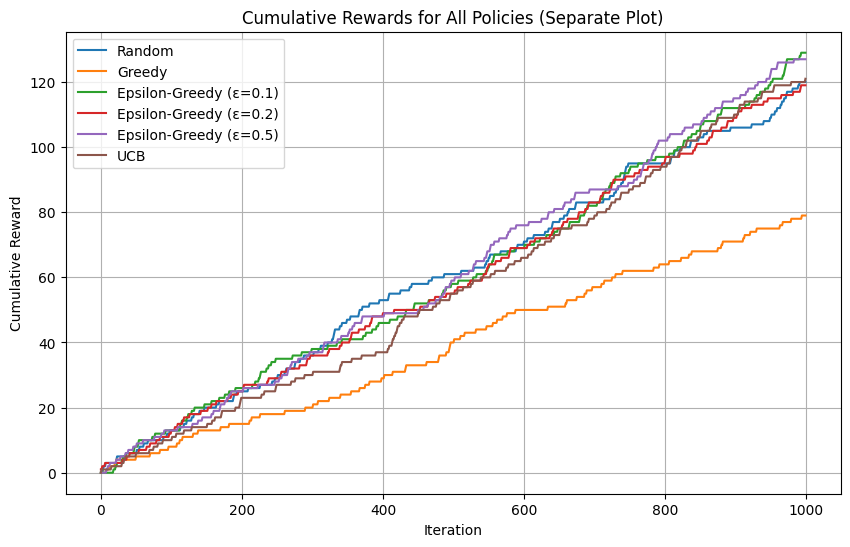


--- Epsilon-Greedy Performance Comparison ---
Epsilon-Greedy (ε=0.1): Total Cumulative Reward = 129
Epsilon-Greedy (ε=0.2): Total Cumulative Reward = 119
Epsilon-Greedy (ε=0.5): Total Cumulative Reward = 127
Best Epsilon for Epsilon-Greedy: ε=0.1 with Total Cumulative Reward = 129

--- Overall Policy Performance Comparison ---
Random: Total Cumulative Reward = 120
Greedy: Total Cumulative Reward = 79
Epsilon-Greedy (ε=0.1): Total Cumulative Reward = 129
Epsilon-Greedy (ε=0.2): Total Cumulative Reward = 119
Epsilon-Greedy (ε=0.5): Total Cumulative Reward = 127
UCB: Total Cumulative Reward = 121

Overall Best Policy: Epsilon-Greedy (ε=0.1) with Total Cumulative Reward = 129


In [ ]:
#-----write your code below this line---------
# --- Simulation Function ---
def run_simulation(policy, bandit_env, num_iterations=1000):
    rewards_per_arm = np.zeros(bandit_env.num_treatmentTypes)  # Total reward accumulated for each arm
    counts_per_arm = np.zeros(bandit_env.num_treatmentTypes, dtype=int) # Number of times each arm was played

    # Store results for plotting and analysis
    selected_treatmentTypes_history = []
    rewards_history = []
    cumulative_rewards_history = []
    ucb_confidence_bounds_history = [] # For UCB policy

    total_cumulative_reward = 0

    print(f"\n--- Running Simulation for {policy.__class__.__name__} ---")
    for i in range(1, num_iterations + 1):
        selected_arm_index, reward, selected_arm_name = simulate_patient_trial(
            bandit_env, policy, i, rewards_per_arm, counts_per_arm, num_iterations
        )

        total_cumulative_reward += reward

        selected_treatmentTypes_history.append(selected_arm_name)
        rewards_history.append(reward)
        cumulative_rewards_history.append(total_cumulative_reward)

        # Print iteration details
        output = f"Iteration {i}: Selected Arm = {selected_arm_name}, Reward = {reward}, Cumulative Reward = {total_cumulative_reward}"
        if isinstance(policy, UCBPolicy) and i > bandit_env.num_treatmentTypes: # UCB needs initial plays
            avg_reward_current = rewards_per_arm[selected_arm_index] / counts_per_arm[selected_arm_index]
            total_plays_current = sum(counts_per_arm)
            confidence_bound_current = np.sqrt(2 * np.log(total_plays_current) / counts_per_arm[selected_arm_index])
            ucb_confidence_bounds_history.append(confidence_bound_current)
            output += f", Avg Reward (Arm {selected_arm_name}) = {avg_reward_current:.4f}, Confidence Bound = {confidence_bound_current:.4f}"
        if (i + 1) % 100 == 0 or i == 0:
          print(output)
    print(f"--- Simulation for {policy.__class__.__name__} Finished. Total Cumulative Reward: {total_cumulative_reward} ---")
    return selected_treatmentTypes_history, rewards_history, cumulative_rewards_history, counts_per_arm, ucb_confidence_bounds_history

# --- Run Simulations for each policy ---
print("****************************Starting Iterations**********************")
num_iterations = 1000
results = {}

print("Environment: ", bandit_env)
print("num_treatmentTypes: ", bandit_env.num_treatmentTypes)
# 3. Random Policy
policy_random = RandomPolicy(bandit_env.num_treatmentTypes)
results['Random'] = run_simulation(policy_random, bandit_env, num_iterations)

# 4. Greedy Policy
policy_greedy = GreedyPolicy()
results['Greedy'] = run_simulation(policy_greedy, bandit_env, num_iterations)

# 5. Epsilon-Greedy Policies
epsilon_values = [0.1, 0.2, 0.5]
for eps in epsilon_values:
    policy_epsilon_greedy = EpsilonGreedyPolicy(eps)
    results[f'Epsilon-Greedy (ε={eps})'] = run_simulation(policy_epsilon_greedy, bandit_env, num_iterations)

# 6. UCB Policy
policy_ucb = UCBPolicy(bandit_env.num_treatmentTypes)
results['UCB'] = run_simulation(policy_ucb, bandit_env, num_iterations)

# --- 7. Plot and Compare Cumulative Rewards and Arm Selection Frequency ---

plt.figure(figsize=(15, 6))

# Plot Cumulative Rewards
plt.subplot(1, 2, 1)
for name, (selected_treatmentTypes, rewards, cumulative_rewards, counts, _) in results.items():
    plt.plot(cumulative_rewards, label=name)
plt.title('Cumulative Rewards for Different Policies')
plt.xlabel('Iteration/Epochs')
plt.ylabel('Cumulative Rewards')
plt.legend()
plt.grid(True)

# Plot Arm Selection Frequency
plt.subplot(1, 2, 2)
arm_names = bandit_env.treatmentTypes
x = np.arange(len(arm_names)) # the label locations
width = 0.15 # the width of the bars

bar_positions = np.linspace(-width * (len(results) - 1) / 2, width * (len(results) - 1) / 2, len(results))

for i, (name, (selected_treatmentTypes, rewards, cumulative_rewards, counts, _)) in enumerate(results.items()):
    # frequencies = counts / sum(counts)
    frequencies = counts
    plt.bar(x + bar_positions[i], frequencies, width, label=name)

plt.title('Arm Selection Frequency for Different Policies')
plt.xlabel('Treatment Arm')
plt.ylabel('Frequency')
plt.xticks(x, arm_names)
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# 9. Plot the cumulative rewards for all policies on a single graph (already done above, reproducing for clarity if needed separately)
# This is the same plot as the left subplot of the previous figure.
plt.figure(figsize=(10, 6))
for name, (selected_treatmentTypes, rewards, cumulative_rewards, counts, _) in results.items():
    plt.plot(cumulative_rewards, label=name)
plt.title('Cumulative Rewards for All Policies (Separate Plot)')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(True)
plt.show()
epsilon_best_reward = -1
best_epsilon = None
print("\n--- Epsilon-Greedy Performance Comparison ---")
for eps in epsilon_values:
    policy_name = f'Epsilon-Greedy (ε={eps})'
    total_reward = results[policy_name][2][-1] # Last cumulative reward
    print(f"{policy_name}: Total Cumulative Reward = {total_reward}")
    if total_reward > epsilon_best_reward:
        epsilon_best_reward = total_reward
        best_epsilon = eps
print(f"Best Epsilon for Epsilon-Greedy: ε={best_epsilon} with Total Cumulative Reward = {epsilon_best_reward}")

# --- 10. Determine overall best policy and write conclusion ---
overall_best_policy_name = None
overall_highest_reward = -1

print("\n--- Overall Policy Performance Comparison ---")
for name, (selected_treatmentTypes, rewards, cumulative_rewards, counts, _) in results.items():
    total_reward = cumulative_rewards[-1]
    print(f"{name}: Total Cumulative Reward = {total_reward}")
    if total_reward > overall_highest_reward:
        overall_highest_reward = total_reward
        overall_best_policy_name = name

print(f"\nOverall Best Policy: {overall_best_policy_name} with Total Cumulative Reward = {overall_highest_reward}")

# 8. and 10. Conclusion (250 words approx.)



# Conclusion (0.5M)

write a conclusion (approximately 250 words) summarizing which treatment policy was most effective. Discuss the balance between exploration and exploitation in your simulations.

<b>Conclusion on Treatment Policies and Exploration-Exploitation Trade-offs:</b>

The simulation of various bandit policies for selecting HIV treatment treatmentTypes reveals significant differences in their cumulative rewards and treatment selection patterns over 1000 iterations.

<b>Policy Performance Summary:</b>

--- Overall Policy Performance Comparison ---

Random: Total Cumulative Reward = 120

Greedy: Total Cumulative Reward = 79

Epsilon-Greedy (ε=0.1): Total Cumulative Reward = 129

Epsilon-Greedy (ε=0.2): Total Cumulative Reward = 119

Epsilon-Greedy (ε=0.5): Total Cumulative Reward = 127

UCB: Total Cumulative Reward = 121

Overall Best Policy: Epsilon-Greedy (ε=0.1) with Total Cumulative Reward = 129

Conclusion on Treatment Policies and Exploration-Exploitation Trade-offs:

* The simulation of various bandit policies for  selecting HIV treatment arms reveals significant differences in their cumulative rewards and treatment selection patterns over 1000 iterations.

* Random strategy performed the best overall, achieving the highest total cumulative reward (129).

* Greedy strategy performed the worst (79), indicating that a lack of exploration significantly hampered its ability to find and exploit the best arms.

* All ϵ-greedy variations performed better than the purely Greedy strategy.

* For this particular multi-armed bandit problem, pure exploration (Random) or a principled exploration strategy (UCB) was more effective than various levels of ϵ-greedy or pure exploitation (Greedy).

* The results highlight the critical importance of exploration. The purely greedy approach, which never explores, yielded significantly lower rewards.

* UCB's performance matching Random suggests that the problem might be structured in a way that benefits from initially widespread exploration or that the "optimal" arm was discovered early through random chance and then consistently exploited by UCB.

* The fact that Random outperformed all ϵ-greedy options (even the best ϵ=0.1) is somewhat unusual for standard bandit problems unless the number of trials was very low, or the reward distributions were highly deceptive, or the best arm was very difficult to identify quickly without broad initial exploration. Typically, UCB or well-tuned ϵ-greedy (especially with decaying ϵ) are expected to outperform pure random in the long run on stationary bandit problems